In [5]:
import jax
import jax.numpy as jnp
import nifty8 as ift
import numpy as np
import resolve as rve
import nifty8.re as jft

from copy import deepcopy
from jax.lax import slice as jax_slice

from aim_resolve import Observation, SignalSpace, plot_arrays, check_type, domain_tree, model_init, correlated_field_model, optimize_kl

jax.config.update("jax_enable_x64", True)

key = jax.random.PRNGKey(123)

In [6]:
class SignalGrid():
    '''Class to represent a signal grid at a specific location in the sky. Use `build` function to create the grid.'''

    def __init__(self, space, center=(0,0), factor=1, distances=(1.,1.)):
        check_type(space, tuple, int)
        check_type(factor, int)
        check_type(center, tuple, int)
        check_type(distances, tuple, float)

        self.space = space
        self.center = center
        self.factor = factor
        self.shape = tuple(d*self.factor for d in self.space)
        self.distances = distances

    def __repr__(self):
        return f'SignalGrid(space={self.space}, center={self.center}, factor={self.factor}, distances={self.distances})'
    
    def __mul__(self, other):
        return self.multiply_space(other)
    
    def __rmul__(self, other):
        return self.__mul__(other)

    @property
    def dom(self):
        return np.array(self.space)

    @property
    def cen(self):
        return np.array(self.center)
    
    @property
    def shp(self):
        return np.array(self.shape)

    @property
    def size(self):
        return self.shp.prod()
    
    @property
    def dis(self):
        return np.array(self.distances) / self.factor
    
    @property
    def coos(self):
        coos = np.indices(self.shp).astype(float)
        coos_T = coos.T.reshape(-1, 2)
        coos_T -= 0.5 * (self.shp - 1)
        coos_T /= self.factor
        coos_T += self.cen
        return coos_T.reshape(coos.T.shape).T

    @property
    def llp(self):
        return self.cen - 0.5 * (self.shp - 1) / self.factor

    @property
    def urp(self):
        return self.cen + 0.5 * (self.shp - 1) / self.factor

    def update(self, space=None, center=None, factor=None, distances=None):
        space = self.space if space is None else space
        center = self.center if center is None else center
        factor = self.factor if factor is None else factor
        distances = self.distances if distances is None else distances
        return SignalGrid(space, center, factor, distances)
    
    def multiply_space(self, factor):
        return SignalGrid.update(self, space=tuple(int(si * factor) for si in self.space))



def downsample(array, factor):
    if factor == 1:
        return array
    if factor in (2,4,8):
        return array.reshape(array.shape[0]//factor, factor, array.shape[1]//factor, factor).mean(axis=(1,3))
    else:
        raise ValueError(f'Invalid zoom factor: {factor}')
    

def upsample(array, factor):
    if factor == 1:
        return array
    elif factor in (2, 4, 8):
        return array.repeat(factor, axis=0).repeat(factor, axis=1)
    else:
        raise ValueError(f'Invalid zoom factor: {factor}')


def map_array(in_array, in_grid, out_grid):
    factor = 1
    if out_grid.factor < in_grid.factor:
        in_array = downsample(in_array, in_grid.factor // out_grid.factor)
        in_grid = in_grid.update(factor=out_grid.factor)
    else:
        factor = out_grid.factor // in_grid.factor
        out_grid = out_grid.update(factor=in_grid.factor)

    if in_grid.center != out_grid.center or in_grid.space != out_grid.space:
        out_array = jnp.zeros(out_grid.shape)

        llp_dif = (out_grid.llp - in_grid.llp).astype('int64')
        urp_dif = (out_grid.urp - in_grid.urp).astype('int64')

        in_min = np.maximum(llp_dif * in_grid.factor, 0)
        in_max = np.minimum(urp_dif * in_grid.factor + in_grid.shp, in_grid.shp)
        in_slc = tuple(slice(in_min[i], in_max[i]) for i in range(2))

        out_min = np.maximum(- llp_dif * out_grid.factor, 0)
        out_max = np.minimum(out_grid.shp - urp_dif * out_grid.factor, out_grid.shp)
        out_slc = tuple(slice(out_min[i], out_max[i]) for i in range(2))
        
        out_array = out_array.at[out_slc].set(in_array[in_slc])
    else:
        out_array = in_array.copy()

    if factor > 1:
        out_array = upsample(out_array, factor)

    return out_array

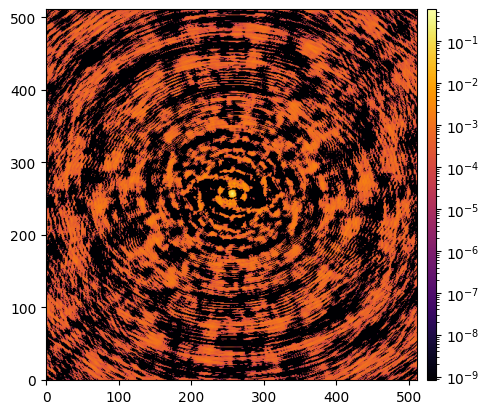

In [7]:
def build_exact_responses(
        obs,
        space,
):
    check_type(space, SignalSpace)
    sdom = ift.RGSpace(space.shape, distances=space.distances)
    sky_dom = rve.default_sky_domain(sdom=sdom)
    R = rve.InterferometryResponse(obs, sky_dom, True, 1e-9, verbosity=0, nthreads=8)

    space_l = space.multiply_fov(2)
    sdom_l = ift.RGSpace(space_l.shape, distances=space_l.distances)
    sky_dom_l = rve.default_sky_domain(sdom=sdom_l)
    R_l = rve.InterferometryResponse(obs, sky_dom_l, True, 1e-9, verbosity=0, nthreads=8)

    dch_l = ift.DomainChangerAndReshaper(R_l.domain[3], R_l.domain)
    R_l = R_l @ dch_l
    dch = ift.DomainChangerAndReshaper(R.domain[3], R.domain)
    R = R @ dch

    N_inv = ift.DiagonalOperator(obs.weight)
    RNR = R.adjoint @ N_inv @ R
    RNR_l = R_l.adjoint @ N_inv @ R_l

    return R, R_l, RNR, RNR_l



def compute_psf_kernel(RNR_l):
    dom_l = RNR_l.domain
    shp_l = dom_l.shape

    delta = np.zeros(shp_l)
    delta[shp_l[0]//2, shp_l[1]//2] = 1 / dom_l.scalar_weight()
    delta = ift.makeField(dom_l, delta)
    kernel = RNR_l(delta)

    return kernel.val



obs = Observation.load('/Users/rf/Development/data/eso_986-1137mhz.npz')
obs = obs.to_double_precision()
obs = obs.to_resolve_obs()

space = SignalSpace.build(shape=(256,256), fov=('1deg', '1deg'))

R, R_l, RNR, RNR_l = build_exact_responses(obs, space)
kernel = compute_psf_kernel(RNR_l)

plot_arrays(kernel, norm='log', dpi=100)

In [8]:
class SignalModel(jft.Model):

    def __init__(self, grid, i0, prefix='sm'):
        self.grid = grid
        self.i0 = i0
        self.prefix = prefix
        super().__init__(domain=self.i0.domain, init=self.i0.init)

    def __call__(self, x, *, out_grid=None):
        res = jnp.exp(self.i0(x))
        if out_grid:
            return map_array(res, self.grid, out_grid)
        return res
    


class ComponentModel(jft.Model):

    def __init__(self, grid, background, *components):
        self.grid = grid
        self.models = (background, ) + components
        self.background = background
        self.components = components

        super().__init__(
            domain = jft.Vector(domain_tree(self.models)), 
            init = model_init(self.models),
        )

    def __call__(self, x, *, out_grid=None):
        out_grid = out_grid if out_grid else self.grid
        res = jnp.zeros(out_grid.shape)
        for m in self.models:
            res += m(x, out_grid=out_grid)
        return res

In [68]:
def jax_fft(grid):
    check_type(grid, SignalGrid)
    dvol = grid.dis.prod()
    return lambda x: dvol * jnp.fft.fftn(x)


def jax_ifft(grid):
    check_type(grid, SignalGrid)
    dvol = 1. / (grid.shp * grid.dis).prod()
    npix = grid.size
    return lambda x: dvol * npix * jnp.fft.ifftn(x)


def jax_fft_convolve(fft_kernel, grid):
    grid_l = grid.update(space=tuple(s*2 for s in grid.space))
    fft_l = jax_fft(grid_l)
    ifft_l = jax_ifft(grid_l)
    padding = grid.shp // 2

    def jax_fft_conv(array):
        p_array = jnp.pad(array, (2*(padding[0],), 2*(padding[1],)))
        c_array = ifft_l(fft_kernel * fft_l(p_array)).real
        s_array = jax_slice(c_array, padding, padding + grid.shp)
        return s_array

    return jax_fft_conv


def shift_kernel(kernel):
    s_kernel = jnp.roll(kernel, -kernel.shape[0]//2, axis=0)
    s_kernel = jnp.roll(s_kernel, -kernel.shape[1]//2, axis=1)
    return s_kernel


def build_fft_kernel(kernel, grid):
    check_type(grid, SignalGrid)
    grid_l = grid.update(space=tuple(s*2 for s in grid.space))
    s_kernel = shift_kernel(kernel)
    f_kernel = jax_fft(grid_l)(s_kernel)
    return f_kernel


def facet_center(factor, shape):
    f_coos = np.linspace(1/factor, 2 - 1/factor, 2*factor - 1)
    f_center = np.array(np.meshgrid(f_coos, f_coos)).T.reshape(-1, 2)
    return f_center * np.array(shape) // 2


def build_facet_kernel(kernel, f_grid, factor):
    f_center = facet_center(factor, kernel.shape)
    n_f = f_center.shape[0]
    f_shape = tuple(s//factor for s in kernel.shape)

    f_kernel = np.zeros((n_f,) + f_shape, dtype='complex128')
    for i in range(n_f):
        slc_i = tuple(slice(int(c) - s//2, int(c) + s//2) for c, s in zip(f_center[i], f_shape))
        f_ker = kernel[slc_i]
        f_kernel[i] = build_fft_kernel(f_ker, f_grid)
    return f_kernel


def build_facet_array(array, factor):
    f_shape = tuple(s//factor for s in array.shape)
    f_array = array.reshape(factor, f_shape[0], factor, f_shape[1])
    f_array = f_array.transpose(0,2,1,3)
    f_array = f_array.reshape(-1, f_shape[0], f_shape[1])
    return f_array


def merge_facet_array(f_array, factor):
    f_shape = f_array.shape[1:]
    array = f_array.reshape(factor, factor, f_shape[0], f_shape[1])
    array = array.transpose(0, 2, 1, 3)
    array = array.reshape(factor*f_shape[0], factor*f_shape[1])
    return array


def facet_indices(factor):
    coos = np.arange(factor)
    a_idx = np.array(np.meshgrid(coos, coos)).T.reshape(-1, 2)
    k_idx = np.arange((2*factor - 1)**2).reshape((2*factor - 1, 2*factor - 1))

    f_idx = np.empty((factor**2, factor**2), dtype='int64')
    for i in range(factor**2):
        slc_i = tuple(slice(int(a_idx[i][j]), int(a_idx[i][j]) + factor) for j in range(2))
        f_idx[i] = k_idx[slc_i].flatten()
    return f_idx[::-1]


def reorder_facet_array(array):
    factor = int(np.sqrt(array.shape[0]))
    grid = np.arange(factor**2).reshape((factor, factor))
    order = grid.T[::-1].flatten()
    return array[order]


def jax_facet_convolve(f_kernel, f_idx, f_grid, factor):

    def jax_facet_conv(array):
        f_array = build_facet_array(array, factor)

        def inner(i, j):
            f_arr = f_array[i]
            f_ker = f_kernel[f_idx[i, j]]
            return jax_fft_convolve(f_ker, f_grid)(f_arr)

        def per_i(i):
            return jax.vmap(lambda j: inner(i, j))(jnp.arange(factor**2))

        f_response = jax.vmap(per_i)(jnp.arange(factor**2))
        f_response = f_response.sum(axis=0)
        response = merge_facet_array(f_response, factor)
        return response
    
    return jax_facet_conv



class FullResponse(jft.Model):

    def __init__(self, model, kernel):
        self.model = model
        self.grid = model.grid
        self.fft_kernel = build_fft_kernel(kernel, self.grid)
        super().__init__(domain = self.model.domain, init = self.model.init)

    def __call__(self, x):
        fft_kernel = jnp.array(self.fft_kernel)
        return jax_fft_convolve(fft_kernel, self.grid)(self.model(x))



class FacetResponse(jft.Model):

    def __init__(self, model, kernel, factor=2):
        self.model = model
        self.grid = model.grid
        self.factor = factor

        self.f_grid = self.grid.update(space=tuple(s//factor for s in self.grid.space))
        self.f_kernel = build_facet_kernel(kernel, self.f_grid, factor)
        self.f_idx = facet_indices(factor)

        super().__init__(domain = self.model.domain, init = self.model.init)

    def __call__(self, x):
        f_kernel = jnp.array(self.f_kernel)
        f_idx = jnp.array(self.f_idx)
        return jax_facet_convolve(f_kernel, f_idx, self.f_grid, self.factor)(self.model(x))

SignalGrid(space=(128, 128), center=(0, 0), factor=1, distances=(0.000272707695624114, 0.000272707695624114))
SignalGrid(space=(20, 30), center=(-3, -5), factor=2, distances=(0.000272707695624114, 0.000272707695624114))
SignalGrid(space=(12, 24), center=(-12, 20), factor=2, distances=(0.000272707695624114, 0.000272707695624114))
SignalGrid(space=(128, 128), center=(0, 0), factor=2, distances=(0.000272707695624114, 0.000272707695624114))


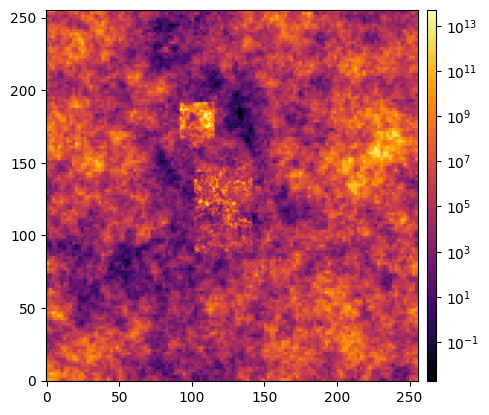

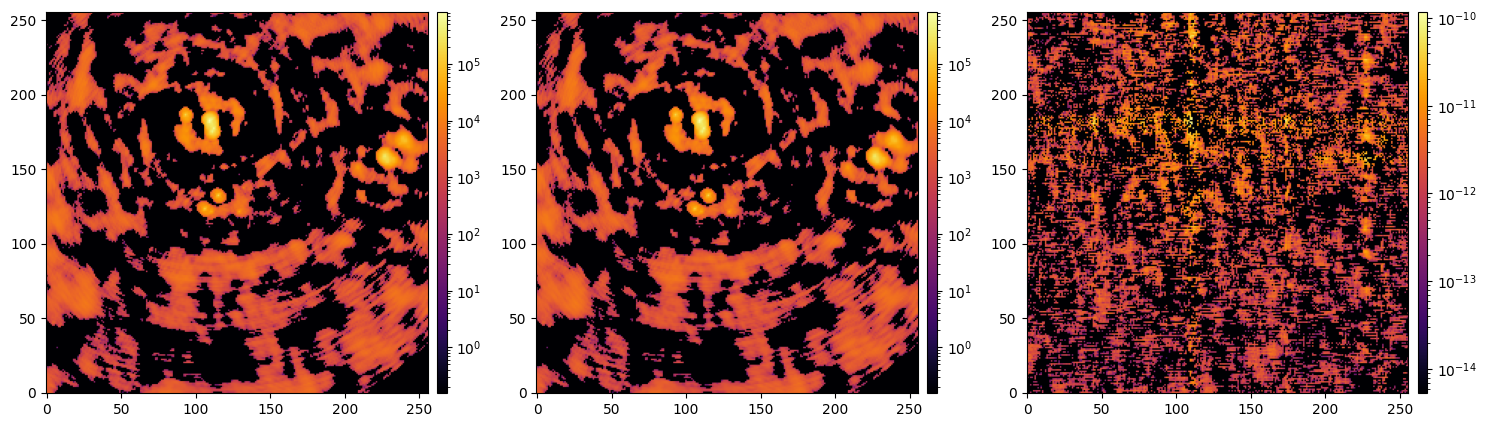

In [69]:
space = SignalSpace.build(shape=(128, 128), fov=('2deg', '2deg'))

factor = 2

bg_grid = SignalGrid(space=(128,128), center=(0,0), factor=1, distances=space.distances)
print(bg_grid)

bg, pw = correlated_field_model(
    prefix='bg ',
    shape=bg_grid.shape,
    distances=bg_grid.distances,
    offset_mean=12,
    offset_std=(1,0.1),
    fluctuations=(5,1),
    loglogavgslope=(-2,0.5),
)
sig_bg = SignalModel(bg_grid, bg, prefix='bg')


t0_grid = SignalGrid(space=(20, 30), center=(-3,-5), factor=factor, distances=space.distances)
print(t0_grid)
t0, pw = correlated_field_model(
    prefix='t0 ',
    shape=t0_grid.shape,
    distances=t0_grid.distances,
    offset_mean=12,
    offset_std=(1,0.1),
    fluctuations=(5,1),
    loglogavgslope=(-2,0.5),
)
sig_t0 = SignalModel(t0_grid, t0, prefix='t0')

t1_grid = SignalGrid(space=(12, 24), center=(-12, 20), factor=factor, distances=space.distances)
print(t1_grid)
t1, pw = correlated_field_model(
    prefix='t1 ',
    shape=t1_grid.shape,
    distances=t1_grid.distances,
    offset_mean=12,
    offset_std=(1,0.1),
    fluctuations=(5,1),
    loglogavgslope=(-2,0.5),
)
sig_t1 = SignalModel(t1_grid, t1, prefix='t1')

grid = SignalGrid(space=bg_grid.space, center=(0,0), factor=factor, distances=space.distances)
print(grid)

signal = ComponentModel(grid, sig_bg, sig_t0, sig_t1)


response = FullResponse(signal, kernel)

f_response = FacetResponse(signal, kernel, factor=4)


key, subkey = jax.random.split(key)
prior_xi = signal.init(subkey)

# plot_arrays([sig_bg(prior_xi), sig_t0(prior_xi), sig_t1(prior_xi), signal(prior_xi)], rows=1, norm='log')
plot_arrays(signal(prior_xi), rows=1, norm='log')

plot_arrays([response(prior_xi), f_response(prior_xi), response(prior_xi) - f_response(prior_xi)], rows=1, norm='log')

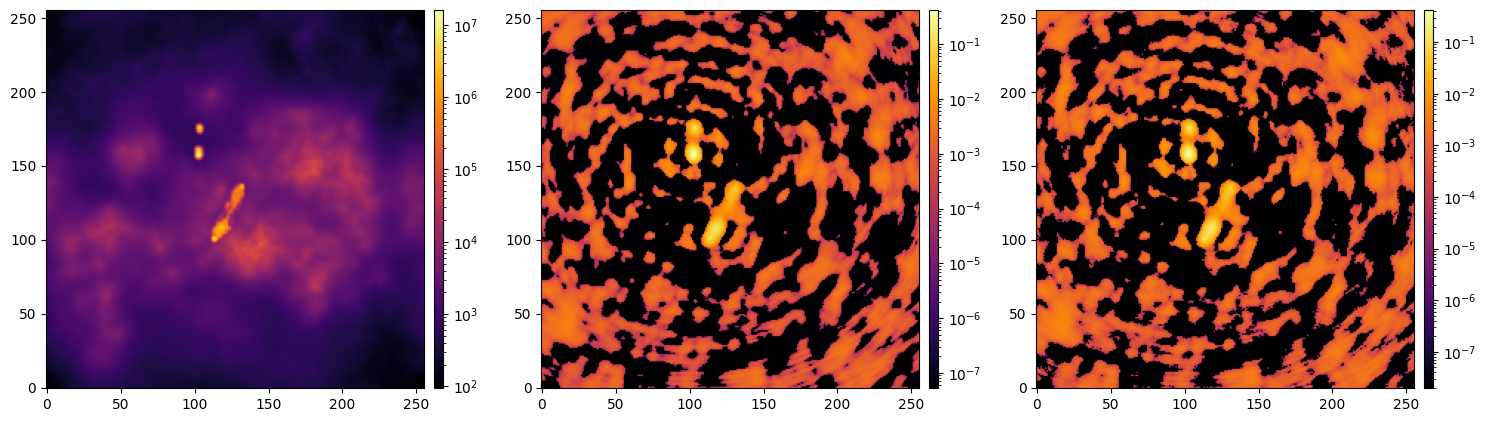

In [70]:
import pickle
import numpy as np
from aim_resolve import OptimizeKLConfig, get_builders, map_signal


base_yml = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/files/base.yml'
exp_yml = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/files/5_pre.yml'

optim_cfg = OptimizeKLConfig.from_file((base_yml, exp_yml), get_builders, 'total')


sky_bg = optim_cfg.instantiate_sec('sky_bg.3')
sky_t0 = optim_cfg.instantiate_sec('sky_o0.3')
sky_t1 = optim_cfg.instantiate_sec('sky_o1.3')
sky_t2 = optim_cfg.instantiate_sec('sky_o2.3')


with open('/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/opt/3_rec/last.pkl', "rb") as f:
    samples, *_ = pickle.load(f)

rec_bg = downsample(samples.mean(sky_bg), 2)
rec_t0 = downsample(map_signal(samples.mean(sky_t0), sky_t0.space, sky_bg.space), 2)
rec_t1 = downsample(map_signal(samples.mean(sky_t1), sky_t1.space, sky_bg.space), 2)
rec_t2 = downsample(map_signal(samples.mean(sky_t2), sky_t2.space, sky_bg.space), 2)

rec = rec_bg + rec_t0 + rec_t1 + rec_t2

fft_kernel = build_fft_kernel(kernel, grid)
truth = jax_fft_convolve(fft_kernel, grid)(rec)

n_std = 1e-4
noise = n_std * jax.random.normal(key, truth.shape)
data = truth + noise

plot_arrays([rec, truth, data], rows=1, norm='log')

OPTIMIZE_KL: Starting 0001


s == p == set()


OPTIMIZE_KL: Iteration 0001 ⛰:+4.2202e+04
OPTIMIZE_KL: #(KL minimization steps) 33
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.3±     0.0, avg:    +0.26±     0.0, #dof:  65536'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²:    0.33±     0.0, avg:    +0.58±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:  0.0067±     0.0, avg:   -0.082±     0.0, #dof:      1'
bg xi                   :: 'reduced χ²:  0.0017±     0.0, avg: -0.00036±     0.0, #dof:  16384'
bg zeromode             :: 'reduced χ²:    0.54±     0.0, avg:    +0.73±     0.0, #dof:      1'
t0 fluctuations         :: 'reduced χ²:    0.49±     0.0, avg:     +0.7±     0.0, #dof:      1'
t0 loglogavgslope       :: 'reduced χ²:  0.0025±     0.0, avg:    -0.05±     0.0, #dof:      1'
t0 xi                   :: 'reduced χ²:  0.0062±     0.0, avg:  -0.0013±     0.0, #dof:   2400'
t0 zeromode             :: 'reduced χ²:   0.044±     0.0, avg:    +0.21±     0.0, #dof:      1'
t1 fluctua

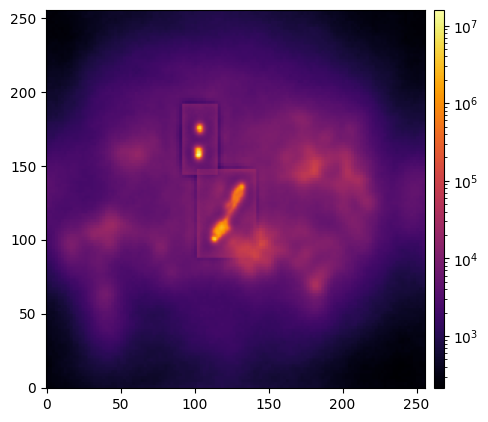

In [ ]:
lh_dct = dict(
    data = data,
    model = f_response,
    noise_cov_inv = None,
    noise_std_inv = (1e-4)**-1,
)

def callback(samples, it):
    plot_arrays([samples.mean(signal)], norm='log')

samples, _ = optimize_kl(
    likelihood=lh_dct, 
    key=4,
    n_total_iterations=1,
    n_samples=0,
    draw_linear_kwargs=dict(
        cg_kwargs=dict(
            name=None,
        ),
    ),
    kl_kwargs=dict(
        minimize_kwargs=dict(
            name=None,
            cg_kwargs=dict(
                name=None
            ),
            maxiter=100,
        ),
    ),
    callback=callback,
    sample_mode='linear_resample',
)

OPTIMIZE_KL: Starting 0001


s == p == set()


OPTIMIZE_KL: Iteration 0001 ⛰:+4.0135e+04
OPTIMIZE_KL: #(KL minimization steps) 37
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.2±     0.0, avg:     +0.2±     0.0, #dof:  65536'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²:    0.38±     0.0, avg:    +0.61±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:  0.0049±     0.0, avg:    -0.07±     0.0, #dof:      1'
bg xi                   :: 'reduced χ²:  0.0018±     0.0, avg: -0.00037±     0.0, #dof:  16384'
bg zeromode             :: 'reduced χ²:    0.58±     0.0, avg:    +0.76±     0.0, #dof:      1'
t0 fluctuations         :: 'reduced χ²:    0.56±     0.0, avg:    +0.75±     0.0, #dof:      1'
t0 loglogavgslope       :: 'reduced χ²: 0.00056±     0.0, avg:   -0.024±     0.0, #dof:      1'
t0 xi                   :: 'reduced χ²:  0.0067±     0.0, avg:  -0.0013±     0.0, #dof:   2400'
t0 zeromode             :: 'reduced χ²:    0.05±     0.0, avg:    +0.22±     0.0, #dof:      1'
t1 fluctua

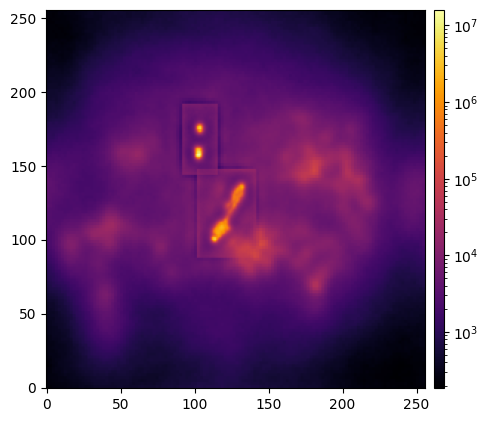

In [67]:
lh_dct = dict(
    data = data,
    model = response,
    noise_cov_inv = None,
    noise_std_inv = (1e-4)**-1,
)

def callback(samples, it):
    plot_arrays([samples.mean(signal)], norm='log')

samples, _ = optimize_kl(
    likelihood=lh_dct, 
    key=4,
    n_total_iterations=1,
    n_samples=0,
    draw_linear_kwargs=dict(
        cg_kwargs=dict(
            maxiter=1000,
            name=None,
        ),
    ),
    kl_kwargs=dict(
        minimize_kwargs=dict(
            name=None,
            cg_kwargs=dict(
                name=None
            ),
            maxiter=100,
        ),
    ),
    callback=callback,
    sample_mode='linear_resample',
)